# Facial Expression Recognition using CNN (Image Folder Version)
This notebook uses a folder-based FER-2013 dataset with a convolutional neural network (CNN) to classify facial expressions.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [2]:

train_dir = 'archive/train'
test_dir = 'archive/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=64,
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=64,
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [3]:

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/Users/amanueltenaw/.pyenv/versions/3.9.9/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,015 (2.36 MB)

 Trainable params: 619,015 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=test_generator
)

Epoch 1/25


/Users/amanueltenaw/.pyenv/versions/3.9.9/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 52s 113ms/step - accuracy: 0.2410 - loss: 1.8154 - val_accuracy: 0.3654 - val_loss: 1.6273
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 55s 122ms/step - accuracy: 0.3632 - loss: 1.6296 - val_accuracy: 0.4511 - val_loss: 1.4223
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 59s 130ms/step - accuracy: 0.4221 - loss: 1.5004 - val_accuracy: 0.4851 - val_loss: 1.3486
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 57s 126ms/step - accuracy: 0.4559 - loss: 1.4270 - val_accuracy: 0.5026 - val_loss: 1.3315
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 58s 130ms/step - accuracy: 0.4750 - loss: 1.3774 - val_accuracy: 0.5120 - val_loss: 1.2558
Epoch 6/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 57s 126ms/step - accuracy: 0.4825 - loss: 1.3546 - val_accuracy: 0.5171 - val_loss: 1.2418
Epoch 7/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 63s 140ms/step - accuracy: 0.4995 - loss: 1.3263 - val_accuracy: 0.5440 - val_loss: 1.2014
Epoch 8/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 57s 127ms/step - accuracy: 0.5007 - loss: 1.3138 - val

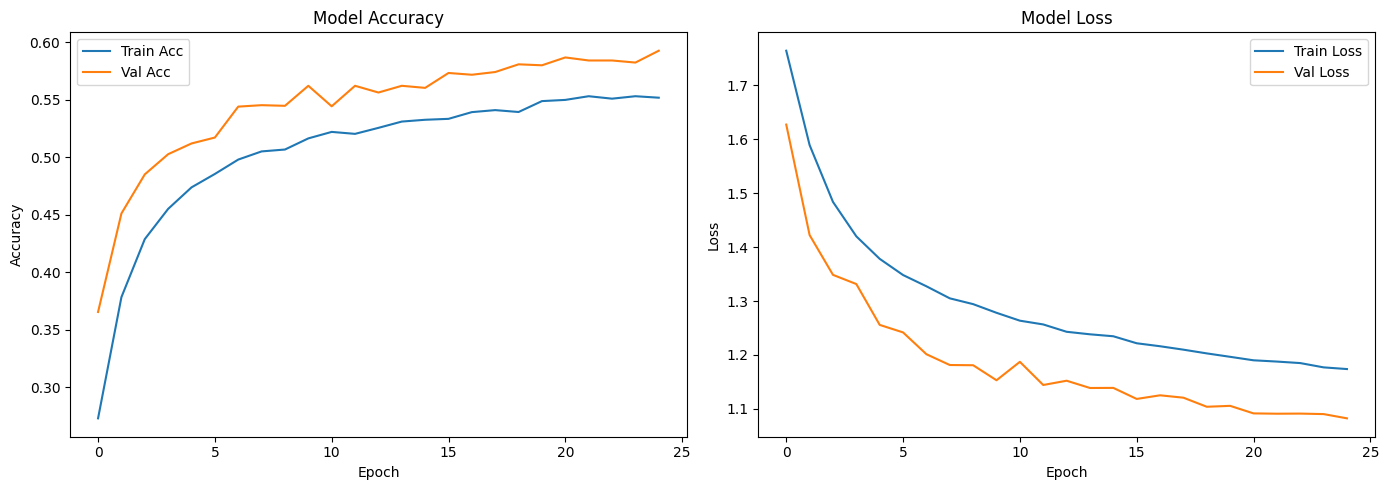

In [5]:

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step


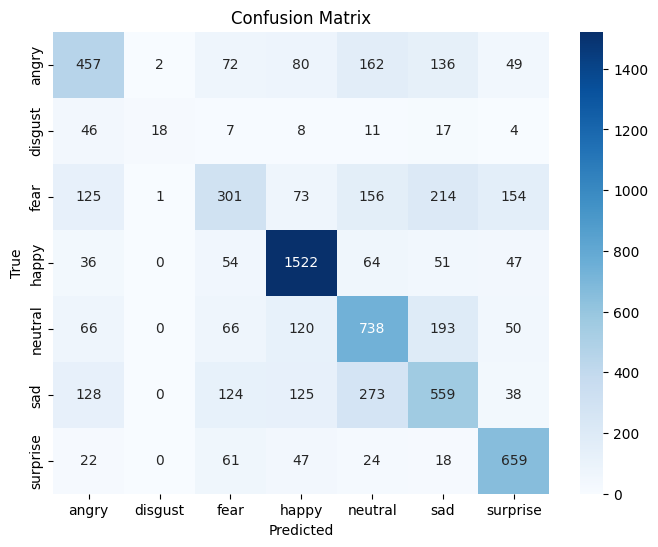

              precision    recall  f1-score   support

       angry       0.52      0.48      0.50       958
     disgust       0.86      0.16      0.27       111
        fear       0.44      0.29      0.35      1024
       happy       0.77      0.86      0.81      1774
     neutral       0.52      0.60      0.55      1233
         sad       0.47      0.45      0.46      1247
    surprise       0.66      0.79      0.72       831

    accuracy                           0.59      7178
   macro avg       0.60      0.52      0.52      7178
weighted avg       0.58      0.59      0.58      7178



In [6]:

import numpy as np
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

In [7]:

model.save("emotion_model.h5")
print("Model saved as emotion_model.h5")


Model saved as emotion_model.h5


In [8]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

model = load_model("emotion_model.h5")

In [20]:

img_path = "your_image.jpg"  
img = image.load_img(img_path, color_mode="grayscale", target_size=(48, 48))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  
img_array = np.expand_dims(img_array, axis=0)  

In [21]:

emotion_classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
pred = model.predict(img_array)
predicted_class = emotion_classes[np.argmax(pred)]
print("Predicted Emotion:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Predicted Emotion: happy


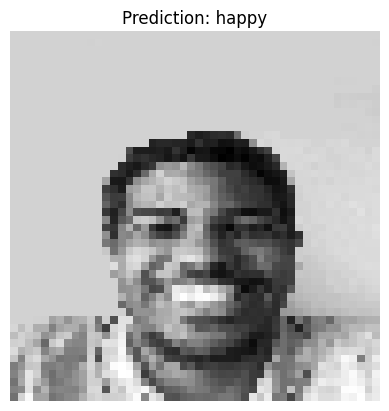

In [ ]:
plt.imshow(img, cmap="gray")
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()